In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [74]:
import pandas as pd
import numpy as np
import cv2
import os
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU, GlobalAveragePooling2D,Rescaling,RandomFlip,RandomRotation,RandomZoom
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import BinaryFocalCrossentropy
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.metrics import AUC, Precision, Recall
import matplotlib.pyplot as plt


In [5]:
import os
import shutil

# Define the base path to your dataset folder in Google Drive
dataset_path = '/content/drive/MyDrive/dataset'

# Define new paths for the train and test splits
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

# Define the paths for the class subdirectories
train_covid_dir = os.path.join(train_dir, 'covid_19')
train_non_covid_dir = os.path.join(train_dir, 'non_covid_19')

test_covid_dir = os.path.join(test_dir, 'covid_19')
test_non_covid_dir = os.path.join(test_dir, 'non_covid_19')

# Create the new directories if they don't already exist
os.makedirs(train_covid_dir, exist_ok=True)
os.makedirs(train_non_covid_dir, exist_ok=True)
os.makedirs(test_covid_dir, exist_ok=True)
os.makedirs(test_non_covid_dir, exist_ok=True)

In [12]:
from sklearn.model_selection import train_test_split

# Get a list of all image file names for each class
covid_images = os.listdir("/content/sample_data/Dataset/covid-19/")
non_covid_images = os.listdir('/content/sample_data/Dataset/non_covid-19/')

# Perform the train-test split for each class
# We'll use an 80/20 split (80% for training, 20% for testing)
train_covid_files, test_covid_files = train_test_split(covid_images, test_size=0.2, random_state=42)
train_non_covid_files, test_non_covid_files = train_test_split(non_covid_images, test_size=0.2, random_state=42)

print(f"COVID-19 train images: {len(train_covid_files)}")
print(f"COVID-19 test images: {len(test_covid_files)}")
print(f"Non-COVID-19 train images: {len(train_non_covid_files)}")
print(f"Non-COVID-19 test images: {len(test_non_covid_files)}")

COVID-19 train images: 1001
COVID-19 test images: 251
Non-COVID-19 train images: 883
Non-COVID-19 test images: 221


In [15]:
# Function to copy files
def copy_files(file_list, source_dir, destination_dir):
    for filename in file_list:
        source_path = os.path.join(source_dir, filename)
        destination_path = os.path.join(destination_dir, filename)
        shutil.copy(source_path, destination_path)

# Copy the training and testing files to their respective directories
original_covid_dir = os.path.join('/content/sample_data/Dataset/', 'covid-19')
original_non_covid_dir = os.path.join('/content/sample_data/Dataset/', 'non_covid-19')

print("Copying COVID-19 training files...")
copy_files(train_covid_files, original_covid_dir, train_covid_dir)

print("Copying COVID-19 testing files...")
copy_files(test_covid_files, original_covid_dir, test_covid_dir)

print("Copying Non-COVID-19 training files...")
copy_files(train_non_covid_files, original_non_covid_dir, train_non_covid_dir)

print("Copying Non-COVID-19 testing files...")
copy_files(test_non_covid_files, original_non_covid_dir, test_non_covid_dir)

print("\nDataset split and organized successfully!")

Copying COVID-19 training files...
Copying COVID-19 testing files...
Copying Non-COVID-19 training files...
Copying Non-COVID-19 testing files...

Dataset split and organized successfully!


In [75]:
img_width = 128
img_height = 128
batch_size = 32

print("Loading training data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/dataset/train',
    image_size=(img_width, img_height),
    batch_size=batch_size,
    label_mode='binary',  # Use 'binary' for two classes
    shuffle=True
)

print("\nLoading testing data...")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/dataset/test',
    image_size=(img_width, img_height),
    batch_size=batch_size,
    label_mode='binary',
    shuffle=False # No need to shuffle the test data
)

Loading training data...
Found 1884 files belonging to 2 classes.

Loading testing data...
Found 472 files belonging to 2 classes.


In [67]:
model = Sequential([

    Conv2D(32, (3, 3), input_shape= (img_width, img_height, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),

    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    # BinaryCrossentropy is the standard loss function for binary classification.
    loss=tf.keras.losses.BinaryCrossentropy(),
    # We track Accuracy, Precision, and Recall as evaluation metrics.
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [76]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,914,309 (37.82 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,609,540 (25.21 MB)

In [77]:
checkpoint_filepath = '/content/drive/MyDrive/best_model.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False, # Set to True if you only want to save weights
    monitor='val_accuracy', # Metric to monitor for improvement
    mode='max', # 'max' since we want to maximize accuracy
    save_best_only=True, # Only save the best model found so far
    verbose=1 # Show a message when a new best model is saved
)

# EarlyStopping callback to stop training when a metric has stopped improving
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Metric to monitor
    min_delta=0.001, # Minimum change to be considered an improvement
    patience=5, # Number of epochs with no improvement after which training will be stopped
    verbose=1,
    mode='min' # 'min' since we want to minimize the validation loss
)


In [78]:
print("\nStarting model training...")
# The model.fit() method trains the network on the provided datasets.
# We set the number of epochs (iterations) and specify the validation data.
history = model.fit(
    train_dataset,
    epochs=200,
    validation_data=test_dataset,
       callbacks=[model_checkpoint_callback, early_stopping_callback]
)

# --- Step 5: Evaluate the model on the test dataset ---
print("\nEvaluating model on test data...")
loss, accuracy, precision, recall = model.evaluate(test_dataset)

print(f"\nFinal Test Loss: {loss:.4f}")
print(f"Final Test Accuracy: {accuracy:.4f}")
print(f"Final Test Precision: {precision:.4f}")
print(f"Final Test Recall: {recall:.4f}")


Starting model training...
Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9747 - loss: 0.0777 - precision_7: 0.9739 - recall_7: 0.9723
Epoch 1: val_accuracy improved from -inf to 0.91949, saving model to /content/drive/MyDrive/best_model.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.9747 - loss: 0.0775 - precision_7: 0.9738 - recall_7: 0.9724 - val_accuracy: 0.9195 - val_loss: 0.2945 - val_precision_7: 0.9507 - val_recall_7: 0.8733
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9743 - loss: 0.0552 - precision_7: 0.9793 - recall_7: 0.9651
Epoch 2: val_accuracy did not improve from 0.91949
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.9743 - loss: 0.0552 - precision_7: 0.9793 - recall_7: 0.9653 - val_accuracy: 0.9195 - val_loss: 0.2822 - val_precision_7: 0.9067 - val_recall_7: 0.9231
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9945 - loss: 0.0204 - precision_7: 0.9969 - recall_7: 0.9914
Epoch 3: val_accuracy did not improve from 0.91949
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.9945 - loss: 0.0204 - precision_7: 0.9968 - recall_7: 0.9915 - val_accuracy: 0.9089 - val_loss: 0.3778 - val_precision_7: 0.9450 - val_recall_7: 0.8552
Epoch 4/200
59/59 ━━━━━

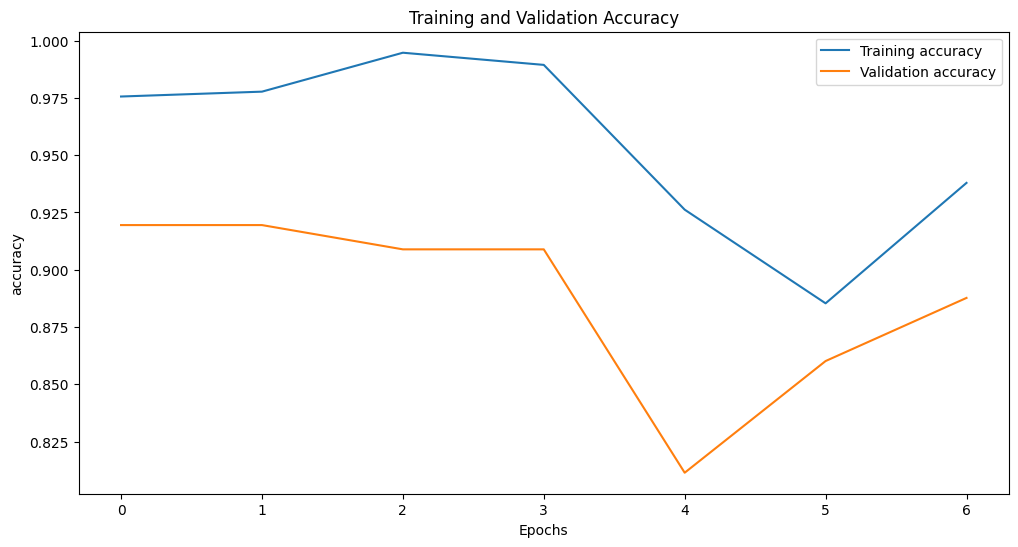

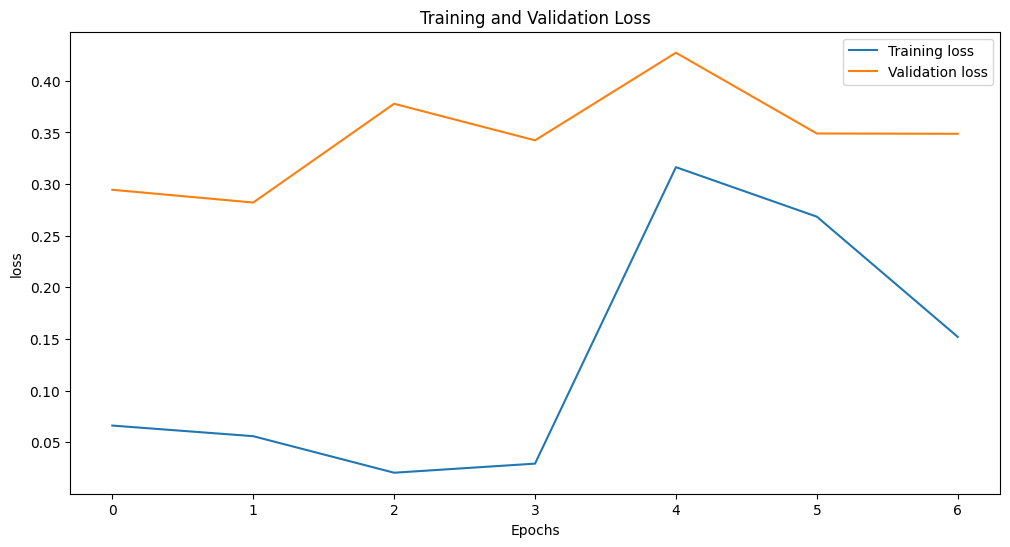

In [82]:
def plot_graphs(history, metric):
    """
    Plots the training and validation graphs for a given metric.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(history.history[metric], label='Training ' + metric)
    plt.plot(history.history['val_' + metric], label='Validation ' + metric)
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend()
    plt.title('Training and Validation ' + metric.capitalize())
    plt.show()

# Plot the accuracy graph
plot_graphs(history, 'accuracy')

# Plot the loss graph
plot_graphs(history, 'loss')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Prediction for Covid (980).png: COVID-19 (100.00% confidence)
Error processing image /content/drive/MyDrive/dataset/test/covid_19/Covid (980).png: name 'prediction_label' is not defined


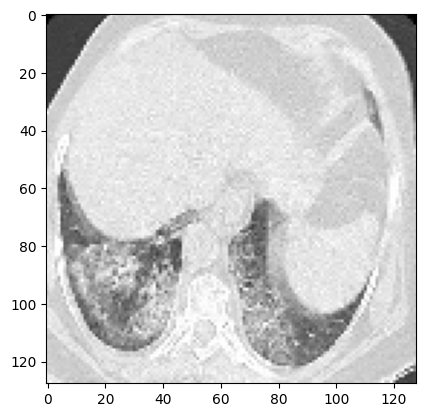

In [80]:
def predict_single_image(image_path):
    try:
        img = load_img(image_path, target_size=(img_width, img_height))

        img_array = img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        predictions = model.predict(img_array)
        probability = predictions[0][0] * 100

        if probability >= 50:
            print(f"\nPrediction for {os.path.basename(image_path)}: Non-COVID-19 ({probability:.2f}% confidence)")
        else:
            print(f"\nPrediction for {os.path.basename(image_path)}: COVID-19 ({(100 - probability):.2f}% confidence)")

        # Display the image with the prediction
        plt.imshow(img)
        plt.title(f"Prediction: {prediction_label} ({probability:.2f}% confidence)")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error processing image {image_path}: {e}")


single_image_path = '/content/drive/MyDrive/dataset/test/covid_19/Covid (980).png'

predict_single_image(single_image_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Prediction for Non-Covid (106).png: Non-COVID-19 (79.20% confidence)
Error processing image /content/drive/MyDrive/dataset/test/non_covid_19/Non-Covid (106).png: name 'prediction_label' is not defined


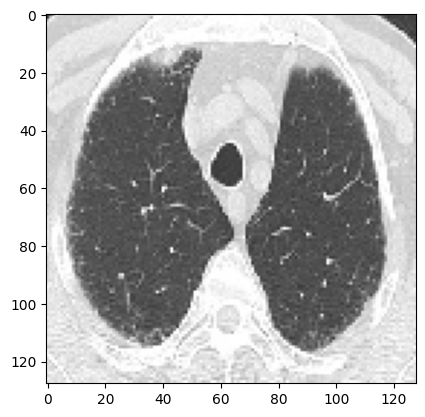

In [81]:
single_image_path = '/content/drive/MyDrive/dataset/test/non_covid_19/Non-Covid (106).png'

predict_single_image(single_image_path)